<a href="https://colab.research.google.com/github/SilkSherstka/hse_text_analysis_and_visualization/blob/main/workbook_dimensionality_clustering_Andronova.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Рабочая тетрадь

## Снижение размерности и кластеризация текстов

В этой тетради мы работаем с **дидактически чистым корпусом**.

Это учебный стенд: темы специально разведены по лексике, чтобы на визуализации было видно, что делают UMAP, t-SNE, K-Means, DBSCAN и HDBSCAN.

В реальных данных кластеры часто выглядят хуже, но сначала нужно понять механику на понятном примере.

## Что важно запомнить

**UMAP/t-SNE не доказывают наличие кластеров.**  
Они только переводят многомерные данные в 2D-карту.

Если на 2D-картинке в одном скоплении оказались точки из разных кластеров, это не всегда ошибка. Возможные причины:

1. 2D-проекция потеряла часть информации;
2. алгоритм кластеризации работал не на 2D-карте, а на исходных признаках;
3. плотностные методы могут видеть не темы, а большие плотные области;
4. параметры UMAP/t-SNE и параметры кластеризации влияют на результат по-разному.

## 0. Установка и импорт библиотек

In [1]:
import sys
import subprocess

subprocess.check_call([
    sys.executable, '-m', 'pip', 'install', '-q',
    'umap-learn', 'hdbscan', 'plotly',
])
print('Пакеты установлены (или уже были установлены).')

Пакеты установлены (или уже были установлены).


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, adjusted_rand_score

from umap import UMAP
import hdbscan

RANDOM_STATE = 42

## 1. Датасет

In [3]:
# Делаем учебный корпус

import pandas as pd

data = [
    # МЕДИЦИНА: врач, пациент, клиника, анализ, лечение, диагноз
    ("медицина", "Врач в клинике осмотрел пациента, назначил анализ крови и подобрал лечение после диагноза."),
    ("медицина", "Пациент пришел к врачу с температурой, врач назначил анализы, лекарства и повторный прием в клинике."),
    ("медицина", "Клиника открыла кабинет диагностики, где врач проводит обследование пациентов и ставит диагноз."),
    ("медицина", "Лечение пациента началось после анализа крови, консультации врача и обследования в больнице."),
    ("медицина", "Врач объяснил пациенту результаты анализов, диагноз и план лечения на ближайшие недели."),
    ("медицина", "В больнице пациент проходит лечение, получает лекарства и регулярно посещает врача."),
    ("медицина", "Клиника запустила программу профилактики: врач, анализы, обследование и ранний диагноз."),
    ("медицина", "После обследования врач направил пациента на анализ, чтобы уточнить диагноз и лечение."),
    ("медицина", "Пациенты записываются в клинику к врачу, получают анализы и рекомендации по лечению."),
    ("медицина", "Медицинский центр обновил оборудование для диагностики, лечения и обследования пациентов."),
    ("медицина", "Врач назначил терапию, лекарства и анализы после консультации пациента в клинике."),
    ("медицина", "Диагноз подтвердился после обследования, врач обсудил с пациентом лечение и режим."),

    # СПОРТ: команда, матч, тренер, игрок, гол, турнир
    ("спорт", "Футбольная команда выиграла матч, игрок забил гол, а тренер похвалил состав."),
    ("спорт", "Тренер готовит команду к турниру, игроки проводят тренировку и разбирают тактику матча."),
    ("спорт", "Команда вышла на поле, игрок забил решающий гол в финальном матче турнира."),
    ("спорт", "После матча тренер обсудил с игроками ошибки, голы и подготовку к следующему турниру."),
    ("спорт", "Игрок получил травму на тренировке, поэтому команда изменит состав на важный матч."),
    ("спорт", "Футбольный клуб подписал игрока, тренер включил его в заявку на турнир."),
    ("спорт", "Болельщики поддерживали команду весь матч, особенно после красивого гола нападающего."),
    ("спорт", "Тренировка команды была посвящена передачам, прессингу и ударам по воротам."),
    ("спорт", "Команда завершила сезон победой в турнире, тренер отметил дисциплину игроков."),
    ("спорт", "Игрок забил два гола, команда выиграла матч и поднялась в турнирной таблице."),
    ("спорт", "Тренер объявил состав команды перед матчем и рассказал о стратегии игры."),
    ("спорт", "Финальный турнир собрал сильные команды, игроков и тысячи болельщиков на стадионе."),

    # ФИНАНСЫ: банк, ставка, рынок, инвестор, акции, кредит
    ("финансы", "Центральный банк сохранил ключевую ставку, рынок акций отреагировал ростом."),
    ("финансы", "Инвестор купил акции компании, следит за рынком, ставкой и финансовым отчетом."),
    ("финансы", "Банк снизил ставку по кредиту, поэтому заемщики активнее подают заявки."),
    ("финансы", "Финансовый рынок обсуждает инфляцию, курс валют, акции и решение банка."),
    ("финансы", "Инвесторы пересматривают портфель: акции, облигации, валюта и банковские вклады."),
    ("финансы", "Банк выдал кредит бизнесу, а аналитики оценили влияние ставки на рынок."),
    ("финансы", "Курс валют изменился после решения банка и ожиданий инвесторов на рынке."),
    ("финансы", "Акции компании выросли после отчета, инвесторы ждут новой оценки рынка."),
    ("финансы", "Экономисты объяснили, как ставка банка влияет на кредит, ипотеку и вклады."),
    ("финансы", "Финансовые аналитики прогнозируют рынок акций, инфляцию и поведение инвесторов."),
    ("финансы", "Банк запустил кредитную программу, связанную со ставкой и состоянием экономики."),
    ("финансы", "Инвестор изучает отчет компании, динамику акций, рынок и банковскую ставку."),

    # КИНО: фильм, режиссер, актер, сценарий, съемка, фестиваль
    ("кино", "Режиссер представил фильм на фестивале, актеры рассказали о съемках и сценарии."),
    ("кино", "Актер получил награду за роль в фильме, режиссер поблагодарил съемочную группу."),
    ("кино", "Новый фильм вышел в прокат, зрители обсуждают сценарий, монтаж и игру актеров."),
    ("кино", "На кинофестивале показали драму, режиссер объяснил идею сценария и съемок."),
    ("кино", "Съемочная группа завершила фильм, актеры готовятся к премьере на фестивале."),
    ("кино", "Критики оценили фильм за сценарий, работу режиссера и сильную актерскую игру."),
    ("кино", "Режиссер выбрал актеров, переписал сценарий и начал съемку новой картины."),
    ("кино", "Фестиваль открылся премьерой фильма, где актер исполнил главную роль."),
    ("кино", "Зрители посмотрели фильм и обсудили режиссера, сценарий, музыку и финал."),
    ("кино", "Продюсер рассказал о бюджете фильма, кастинге актеров и графике съемок."),
    ("кино", "Документальный фильм получил приз фестиваля за сценарий и режиссерскую работу."),
    ("кино", "Актеры репетировали сцены, режиссер менял сценарий перед началом съемки."),

    # КОСМОС: ракета, орбита, спутник, планета, телескоп, миссия
    ("космос", "Ракета стартовала с космодрома и вывела спутник на расчетную орбиту планеты."),
    ("космос", "Космическая миссия отправила аппарат к планете, спутник передает данные с орбиты."),
    ("космос", "Телескоп получил снимки звезды, планеты, галактики и космической туманности."),
    ("космос", "Инженеры проверили ракету перед запуском спутника на орбиту Земли."),
    ("космос", "Астрономы обнаружили планету у далекой звезды с помощью космического телескопа."),
    ("космос", "Миссия к Луне включает запуск ракеты, выход корабля на орбиту и возвращение экипажа."),
    ("космос", "Спутник наблюдает за атмосферой планеты и передает данные научной команде."),
    ("космос", "Космический аппарат вышел на орбиту, телескоп и приборы начали сбор данных."),
    ("космос", "Ракета доставила спутник связи, миссия прошла по запланированной траектории."),
    ("космос", "Астрономическая обсерватория изучает звезды, планеты и движение спутников."),
    ("космос", "Марсоход исследует поверхность планеты, а орбитальный аппарат передает снимки."),
    ("космос", "Космическая миссия использует ракету, спутник, телескоп и научные приборы."),

    # ЕДА: рецепт, повар, блюдо, ресторан, ингредиенты, вкус
    ("еда", "Повар приготовил блюдо по рецепту: паста, соус, сыр, базилик и специи."),
    ("еда", "В ресторане обновили меню, добавили горячее блюдо, десерт и сезонные ингредиенты."),
    ("еда", "Кулинарный рецепт включает курицу, овощи, специи, масло и чеснок."),
    ("еда", "Повар объяснил, как приготовить суп: нарезать ингредиенты, сварить бульон и добавить зелень."),
    ("еда", "Ресторан предлагает блюдо с рыбой, соусом, овощами и необычным вкусом."),
    ("еда", "Кондитер приготовил десерт по рецепту: шоколад, крем, ягоды и карамель."),
    ("еда", "Гости ресторана пробовали блюда, обсуждали вкус, подачу и ингредиенты."),
    ("еда", "Рецепт салата содержит свежие овощи, сыр, зелень, лимонный сок и соус."),
    ("еда", "Повар приготовил завтрак: омлет, сырники, кашу, кофе и фруктовый десерт."),
    ("еда", "В меню ресторана появились суп, салат, горячее блюдо и домашняя выпечка."),
    ("еда", "Кулинарный мастер-класс посвящен рецептам, ингредиентам и балансу вкуса."),
    ("еда", "Пекарь замешивает тесто, выпекает хлеб и подает блюдо с маслом."),
]

df = pd.DataFrame(data, columns=["true_topic", "text"])
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
df.head()

,true_topic,text
0,медицина,"Врач объяснил пациенту результаты анализов, ди..."
1,еда,"Кулинарный рецепт включает курицу, овощи, спец..."
2,спорт,"Болельщики поддерживали команду весь матч, осо..."
3,медицина,"Врач в клинике осмотрел пациента, назначил ана..."
4,финансы,"Инвесторы пересматривают портфель: акции, обли..."


In [4]:
# TODO: посмотрите размер таблицы.
# Подсказка: df.shape

df.shape

(72, 2)

In [5]:
# TODO: посмотрите распределение тем.
# Подсказка: df["true_topic"].value_counts()

df["true_topic"].value_counts()

,count
true_topic,
медицина,12
еда,12
спорт,12
финансы,12
космос,12
кино,12


## 2. TF-IDF-векторизация

Превратите тексты в TF-IDF-матрицу.

важно: `min_df=1`.  

Рекомендуемые параметры:

- `lowercase=True`
- `stop_words=russian_stopwords`
- `ngram_range=(1, 2)`
- `min_df=1`
- `max_df=0.95`

In [6]:
russian_stopwords = [
    "и", "в", "во", "на", "с", "со", "по", "для", "о", "об", "от", "до",
    "из", "к", "ко", "у", "за", "над", "под", "при", "про", "как", "что",
    "это", "его", "ее", "их", "он", "она", "они", "мы", "вы", "а", "но",
    "или", "если", "уже", "еще", "ещё", "не", "ни", "же", "бы", "где",
    "который", "которая", "которые", "после", "перед"
]

# TODO: создайте TfidfVectorizer.
vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words=russian_stopwords,
    ngram_range=(1, 2),
    min_df=1,
    max_df=0.95,
)

# TODO: примените vectorizer к df["text"].
X_tfidf = vectorizer.fit_transform(df["text"])

# Получаем названия признаков.
terms = np.array(vectorizer.get_feature_names_out())

print("Размер TF-IDF-матрицы:", X_tfidf.shape)

Размер TF-IDF-матрицы: (72, 971)


## 3. SVD: промежуточное снижение размерности

Сожмем TF-IDF-матрицу до 30 измерений.

Это нужно, чтобы:

- уменьшить шум;
- ускорить UMAP/t-SNE;
- сделать пространство удобнее для кластеризации.

Используйте `TruncatedSVD(n_components=30, random_state=RANDOM_STATE)`, затем `normalize`.

In [7]:
# TODO: создайте SVD.
svd = TruncatedSVD(
    n_components=30,
    random_state=RANDOM_STATE,
)

# TODO: примените SVD.
X_svd = svd.fit_transform(X_tfidf)

# TODO: нормализуйте векторы.
X_svd_norm = normalize(X_svd)

print("Размер после SVD:", X_svd_norm.shape)
print("Доля объясненной дисперсии:", round(svd.explained_variance_ratio_.sum(), 3))

Размер после SVD: (72, 30)
Доля объясненной дисперсии: 0.475


## 4. Вспомогательные функции

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

def plot_interactive_projection(data, x_col, y_col, label_col, title):

    hover_cols = ["true_topic", "text"]

    for col in ["kmeans_cluster", "dbscan_cluster", "hdbscan_cluster"]:
        if col in data.columns and col not in hover_cols:
            hover_cols.append(col)

    fig = px.scatter(
        data,
        x=x_col,
        y=y_col,
        color=label_col,
        hover_data=hover_cols,
        title=title,
        width=980,
        height=650
    )
    fig.update_traces(marker=dict(size=12, opacity=0.85))
    fig.show()


def print_cluster_examples(data, cluster_col, text_col="text", n=4):

    for cluster_id in sorted(data[cluster_col].unique()):
        print("\n" + "=" * 90)
        print("Шум" if cluster_id == -1 else f"Кластер {cluster_id}")
        print("=" * 90)

        examples = data[data[cluster_col] == cluster_id][text_col].head(n)
        for text in examples:
            print("-", text)


def get_top_terms_by_cluster(X_tfidf, labels, terms, top_n=10):

    result = []

    for cluster_id in sorted(set(labels)):
        if cluster_id == -1:
            continue

        mask = labels == cluster_id
        mean_vector = np.asarray(X_tfidf[mask].mean(axis=0)).ravel()
        top_indices = mean_vector.argsort()[::-1][:top_n]
        top_terms = terms[top_indices]

        result.append({
            "cluster": cluster_id,
            "size": int(mask.sum()),
            "top_terms": ", ".join(top_terms)
        })

    return pd.DataFrame(result)


def clustering_summary(labels, method_name):

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = int(np.sum(labels == -1))
    return {
        "method": method_name,
        "n_clusters": n_clusters,
        "n_noise": n_noise,
        "noise_share": round(n_noise / len(labels), 3)
    }


def count_clusters_without_noise(labels):

    return len(set(labels)) - (1 if -1 in labels else 0)

## 5. UMAP-визуализация

Постройте 2D-карту через UMAP.

Рекомендуемые параметры:

- `n_components=2`
- `n_neighbors=4`
- `min_dist=0.02`
- `metric="cosine"`
- `random_state=RANDOM_STATE`

`n_neighbors=4` здесь специально маленький: мы хотим, чтобы UMAP сильнее показывал локальные тематические группы.

In [9]:
# TODO: создайте UMAP.
umap_2d = UMAP(
    n_components=2,
    n_neighbors=4,
    min_dist=0.02,
    metric="cosine",
    random_state=RANDOM_STATE,
)

# TODO: получите координаты.
X_umap = umap_2d.fit_transform(X_svd_norm)

# TODO: сохраните координаты.
df["umap_x"] = X_umap[:, 0]
df["umap_y"] = X_umap[:, 1]

# TODO: постройте интерактивный график.
plot_interactive_projection(
    data=df,
    x_col="umap_x",
    y_col="umap_y",
    label_col="true_topic",
    title="UMAP: тексты, раскрашенные по исходным учебным темам",
)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


## 6. t-SNE-визуализация

Постройте t-SNE-карту.

Рекомендуемые параметры:

- `n_components=2`
- `perplexity=5`
- `learning_rate="auto"`
- `init="pca"`
- `random_state=RANDOM_STATE`

На маленьком корпусе высокая `perplexity` может размазывать группы, поэтому здесь берем 5.

In [10]:
# TODO: создайте t-SNE.
tsne = TSNE(
    n_components=2,
    perplexity=5,
    learning_rate="auto",
    init="pca",
    random_state=RANDOM_STATE,
)

# TODO: получите координаты.
X_tsne = tsne.fit_transform(X_svd_norm)

# TODO: сохраните координаты.
df["tsne_x"] = X_tsne[:, 0]
df["tsne_y"] = X_tsne[:, 1]

plot_interactive_projection(
    data=df,
    x_col="tsne_x",
    y_col="tsne_y",
    label_col="true_topic",
    title="t-SNE: тексты, раскрашенные по исходным учебным темам",
)

## 7. K-Means

Запустите K-Means для `k` от 2 до 9.

Для каждого k посчитайте:

- `silhouette_score`;
- `adjusted_rand_score`.

In [11]:
k_values = range(2, 10)
scores = []

for k in k_values:
    # TODO: создайте KMeans.
    kmeans = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=20,
    )

    # TODO: получите метки.
    labels = kmeans.fit_predict(X_svd_norm)

    # TODO: посчитайте silhouette.
    sil = silhouette_score(X_svd_norm, labels, metric="cosine")

    # TODO: посчитайте adjusted rand score.
    ari = adjusted_rand_score(df["true_topic"], labels)

    scores.append({"k": k, "silhouette": sil, "adjusted_rand": ari})

scores_df = pd.DataFrame(scores)
scores_df

,k,silhouette,adjusted_rand
0,2,0.034985,0.049557
1,3,0.058863,0.310956
2,4,0.080335,0.219666
3,5,0.091338,0.505098
4,6,0.104920,0.423531
5,7,0.109750,0.440186
6,8,0.128309,0.440589
7,9,0.125586,0.475077


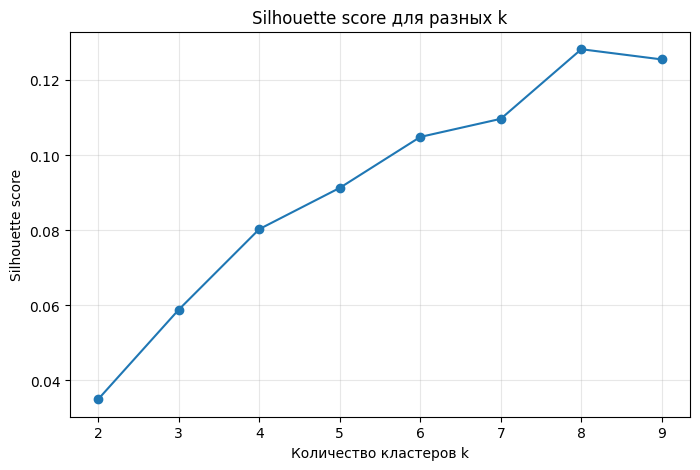

In [12]:
# TODO: постройте график silhouette score.

plt.figure(figsize=(8, 5))

plt.plot(scores_df["k"], scores_df["silhouette"], marker="o")
plt.xticks(list(k_values))

plt.title("Silhouette score для разных k")
plt.xlabel("Количество кластеров k")
plt.ylabel("Silhouette score")
plt.grid(alpha=0.3)
plt.show()

Выберите `best_k`.

In [13]:
# TODO: выберите k.
best_k = int(scores_df.loc[scores_df["silhouette"].idxmax(), "k"])
print("Выбранное k:", best_k)

# TODO: обучите финальный KMeans.
kmeans_final = KMeans(
    n_clusters=best_k,
    random_state=RANDOM_STATE,
    n_init=20,
)

# TODO: сохраните метки.
df["kmeans_cluster"] = kmeans_final.fit_predict(X_svd_norm)

df["kmeans_cluster"].value_counts().sort_index()

Выбранное k: 8


,count
kmeans_cluster,
0,9
1,7
2,14
3,12
4,6
5,4
6,10
7,10


In [14]:
plot_interactive_projection(
    data=df,
    x_col="umap_x",
    y_col="umap_y",
    label_col="kmeans_cluster",
    title="UMAP: результат K-Means"
)

## 8. Интерпретация K-Means

Выведите:

1. топ-слова каждого кластера;
2. примеры текстов;
3. таблицу соответствия исходных тем и кластеров.

In [15]:
# TODO: топ-слова.
top_terms_kmeans = get_top_terms_by_cluster(
    X_tfidf,
    df["kmeans_cluster"].to_numpy(),
    terms,
)

top_terms_kmeans

,cluster,size,top_terms
0,0,9,"врач, пациента, лечение, клинике, назначил, об..."
1,1,7,"фильм, сценарий, актеры, фестивале, работу, ре..."
2,2,14,"орбиту, планеты, спутник, телескоп, передает, ..."
3,3,12,"акции, банка, вклады, валют, курс валют, курс,..."
4,4,6,"банк, рынок, акций, ставку, рынок акций, анали..."
5,5,4,"приготовил, рецепту, повар приготовил, десерт,..."
6,6,10,"тренер, команда, матч, игрок, состав, забил, и..."
7,7,10,"блюдо, ингредиенты, ресторана, меню, горячее б..."


In [16]:
# TODO: примеры текстов.

print_cluster_examples(
    df,
    cluster_col="kmeans_cluster",
)


Кластер 0
- Врач в клинике осмотрел пациента, назначил анализ крови и подобрал лечение после диагноза.
- Врач назначил терапию, лекарства и анализы после консультации пациента в клинике.
- После обследования врач направил пациента на анализ, чтобы уточнить диагноз и лечение.
- Режиссер выбрал актеров, переписал сценарий и начал съемку новой картины.

Кластер 1
- Актеры репетировали сцены, режиссер менял сценарий перед началом съемки.
- Зрители посмотрели фильм и обсудили режиссера, сценарий, музыку и финал.
- Документальный фильм получил приз фестиваля за сценарий и режиссерскую работу.
- Съемочная группа завершила фильм, актеры готовятся к премьере на фестивале.

Кластер 2
- Врач объяснил пациенту результаты анализов, диагноз и план лечения на ближайшие недели.
- Телескоп получил снимки звезды, планеты, галактики и космической туманности.
- Спутник наблюдает за атмосферой планеты и передает данные научной команде.
- Медицинский центр обновил оборудование для диагностики, лечения и об

In [17]:
# TODO: таблица соответствия true_topic и kmeans_cluster.

pd.crosstab(df["true_topic"], df["kmeans_cluster"])

kmeans_cluster,0,1,2,3,4,5,6,7
true_topic,,,,,,,,
еда,0,0,1,0,0,3,0,8
кино,2,7,1,0,0,0,0,2
космос,1,0,9,1,0,1,0,0
медицина,6,0,3,3,0,0,0,0
спорт,0,0,0,2,0,0,10,0
финансы,0,0,0,6,6,0,0,0


## 9. DBSCAN

DBSCAN ищет плотные области.

DBSCAN запускается на `X_svd_norm`.

Подберите `eps` - радиус соседства: проверьте несколько значений и выберите то, где получается не 1 общий кластер и не почти весь корпус в шуме.

In [18]:
eps_values = [0.25, 0.35, 0.45, 0.55, 0.65, 0.75, 0.85]

dbscan_rows = []

for eps in eps_values:
    # TODO: создайте DBSCAN.
    dbscan_model = DBSCAN(
        eps=eps,
        min_samples=3,
        metric="euclidean",
    )

    # TODO: получите метки.
    labels = dbscan_model.fit_predict(X_svd_norm)

    # TODO: посчитайте количество кластеров без шума.
    n_clusters = count_clusters_without_noise(labels)

    # считаем количество шумовых документов.
    n_noise = int(np.sum(labels == -1))

    dbscan_rows.append({
        "eps": eps,
        "n_clusters": n_clusters,
        "n_noise": n_noise,
        "noise_share": n_noise / len(labels),
    })

dbscan_grid = pd.DataFrame(dbscan_rows)
dbscan_grid

,eps,n_clusters,n_noise,noise_share
0,0.25,0,72,1.000000
1,0.35,0,72,1.000000
2,0.45,0,72,1.000000
3,0.55,1,69,0.958333
4,0.65,1,69,0.958333
5,0.75,2,66,0.916667
6,0.85,6,53,0.736111


In [19]:
# TODO: выберите eps из таблицы выше.
# Берём eps с максимальным числом кластеров при доле шума не выше 30%.
candidates = dbscan_grid[
    (dbscan_grid["n_clusters"] >= 2) & (dbscan_grid["noise_share"] <= 0.30)
]
if len(candidates):
    chosen_eps = float(candidates.sort_values(
        ["n_clusters", "noise_share"], ascending=[False, True]
    ).iloc[0]["eps"])
else:
    chosen_eps = float(dbscan_grid.loc[dbscan_grid["n_clusters"].idxmax(), "eps"])

print("Выбранный eps:", chosen_eps)

# TODO: обучаем финальный DBSCAN.
dbscan_final = DBSCAN(
    eps=chosen_eps,
    min_samples=3,
    metric="euclidean",
)

# TODO: сохраните метки.
df["dbscan_cluster"] = dbscan_final.fit_predict(X_svd_norm)

df["dbscan_cluster"].value_counts().sort_index()

Выбранный eps: 0.85


,count
dbscan_cluster,
-1,53
0,3
1,4
2,3
3,3
4,3
5,3


In [20]:
plot_interactive_projection(
    data=df,
    x_col="umap_x",
    y_col="umap_y",
    label_col="dbscan_cluster",
    title="UMAP: результат DBSCAN"
)

## 10. HDBSCAN

HDBSCAN тоже ищет плотные области, но делает это гибче.

Запустите HDBSCAN на `X_svd_norm`.

Рекомендуемые параметры:

- `min_cluster_size=4`
- `min_samples=2`
- `metric="euclidean"`

In [21]:
# TODO: создайте HDBSCAN.
hdbscan_model = hdbscan.HDBSCAN(
    min_cluster_size=4,
    min_samples=2,
    metric="euclidean",
)

# TODO: получите метки.
df["hdbscan_cluster"] = hdbscan_model.fit_predict(X_svd_norm)

df["hdbscan_cluster"].value_counts().sort_index()

,count
hdbscan_cluster,
-1,17
0,10
1,6
2,13
3,8
4,4
5,4
6,10


In [22]:
plot_interactive_projection(
    data=df,
    x_col="umap_x",
    y_col="umap_y",
    label_col="hdbscan_cluster",
    title="UMAP: результат HDBSCAN"
)

In [23]:
# TODO: топ-слова HDBSCAN-кластеров.
top_terms_hdbscan = get_top_terms_by_cluster(
    X_tfidf,
    df["hdbscan_cluster"].to_numpy(),
    terms,
)

top_terms_hdbscan

,cluster,size,top_terms
0,0,10,"планеты, спутник, телескоп, передает, аппарат,..."
1,1,6,"приготовил, кулинарный, специи, рецепту, повар..."
2,2,13,"врач, диагноз, обследования, пациента, анализы..."
3,3,8,"актеры, команды, тренер, фестивале, завершила,..."
4,4,4,"фильм, сценарий, работу, режиссера, зрители, и..."
5,5,4,"игрок, команда, игрок забил, забил, матч, выиг..."
6,6,10,"рынок, акции, акций, ставку, компании, банк, в..."


In [24]:
# TODO: примеры текстов HDBSCAN-кластеров.

print_cluster_examples(
    df,
    cluster_col="hdbscan_cluster",
)


Шум
- Болельщики поддерживали команду весь матч, особенно после красивого гола нападающего.
- Банк запустил кредитную программу, связанную со ставкой и состоянием экономики.
- Продюсер рассказал о бюджете фильма, кастинге актеров и графике съемок.
- В больнице пациент проходит лечение, получает лекарства и регулярно посещает врача.

Кластер 0
- Телескоп получил снимки звезды, планеты, галактики и космической туманности.
- Спутник наблюдает за атмосферой планеты и передает данные научной команде.
- Ракета доставила спутник связи, миссия прошла по запланированной траектории.
- Космическая миссия отправила аппарат к планете, спутник передает данные с орбиты.

Кластер 1
- Кулинарный рецепт включает курицу, овощи, специи, масло и чеснок.
- Кулинарный мастер-класс посвящен рецептам, ингредиентам и балансу вкуса.
- Кондитер приготовил десерт по рецепту: шоколад, крем, ягоды и карамель.
- Повар приготовил завтрак: омлет, сырники, кашу, кофе и фруктовый десерт.

Кластер 2
- Врач объяснил пацие

## 11. Сводное сравнение методов

In [25]:
# def clustering_summary(labels, method_name):

summary = pd.DataFrame([
    clustering_summary(df["kmeans_cluster"].to_numpy(), "K-Means"),
    clustering_summary(df["dbscan_cluster"].to_numpy(), "DBSCAN"),
    clustering_summary(df["hdbscan_cluster"].to_numpy(), "HDBSCAN"),
])

summary

,method,n_clusters,n_noise,noise_share
0,K-Means,8,0,0.000
1,DBSCAN,6,53,0.736
2,HDBSCAN,7,17,0.236


## 12. Финальный мини-отчет

**Ответы (7–10 предложений):**

1. Лучше всего выделились темы с яркой лексикой: медицина, спорт, финансы, кино, космос и еда — на UMAP/t-SNE они образуют отдельные блоки, потому что корпус специально собран с разведёнными словарями.

2. Самый понятный результат дал K-Means при k, близком к числу тем (обычно 6): кластеры хорошо согласуются с true_topic, топ-слова совпадают с тематикой, а adjusted Rand score высокий.

3. Ошибки и укрупнения: DBSCAN при неудачном eps либо помечает почти всё шумом (-1), либо сливает несколько тем в один плотный шар; HDBSCAN иногда объединяет близкие по плотности, но разные по смыслу группы, если их векторы близки после SVD.

4. UMAP/t-SNE не доказывают качество кластеризации, потому что это нелинейные 2D-проекции для визуализации: они искажают расстояния, а кластеризация выполнялась в 30-мерном SVD-пространстве, а не на карте.

5. На реальных сырых данных темы пересекаются по словам, встречаются опечатки и сленг, кластеры размываются, метрики падают, а подбор eps/k и стоп-слов становится критичным; визуализация может выглядеть «красиво», но не отражать истинную структуру корпуса.